In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator # Standard library for elbow detection

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '20_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top20_matches_all_scores.csv'
SAVE_PLOT = "rank_validation_elbow.png"

def find_optimal_k(file_path):
    # 1. Load data
    df = pd.read_csv(file_path)
    
    # 2. Average the combined_score across all samples and genes by Rank
    # This gives us a "global" performance curve of your matching algorithm
    rank_stats = df.groupby('rank')['combined_score'].mean().reset_index()
    
    ranks = rank_stats['rank'].values
    scores = rank_stats['combined_score'].values

    # 3. Find the Elbow Point
    # S=1.0 is sensitivity; curve is 'decreasing' because score drops as rank increases
    kn = KneeLocator(ranks, scores, curve='decreasing', direction='convex', S=1.0)
    elbow_rank = kn.knee

    # 4. Visualization
    plt.figure(figsize=(10, 6))
    plt.plot(ranks, scores, 'o-', color='teal', label='Mean Combined Score', linewidth=2)
    
    if elbow_rank:
        plt.axvline(x=elbow_rank, color='red', linestyle='--', 
                    label=f'Optimal Elbow (Rank {elbow_rank})')
        plt.annotate(f'Elbow at {elbow_rank}', xy=(elbow_rank, scores[elbow_rank-1]), 
                     xytext=(elbow_rank+2, scores[elbow_rank-1]+0.05),
                     arrowprops=dict(facecolor='black', shrink=0.05))
        
    plt.title('Mathematical Validation of Rank Cutoff (Top K)', fontsize=14, fontweight='bold')
    plt.xlabel('Rank (1 = Best Match)', fontsize=12)
    plt.ylabel('Mean Combined Similarity Score', fontsize=12)
    plt.xticks(np.arange(1, max(ranks)+1, 1))
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    print(f"--- Analysis Complete ---")
    print(f"The mathematical elbow point is at Rank: {elbow_rank}")
    print(f"This suggests that matches after Rank {elbow_rank} are likely background noise.")
    
    #plt.savefig(SAVE_PLOT, dpi=300)
    plt.show()

if __name__ == "__main__":
    try:
        find_optimal_k(INPUT_FILE)
    except Exception as e:
        print(f"Error: {e}")
        print("Note: You may need to install kneed: pip install kneed")

Error: Please check that the curve and direction arguments are valid.
Note: You may need to install kneed: pip install kneed


Analysis complete. Optimal rank cutoff found at: 6
Plot saved as: rank_validation_elbow.png


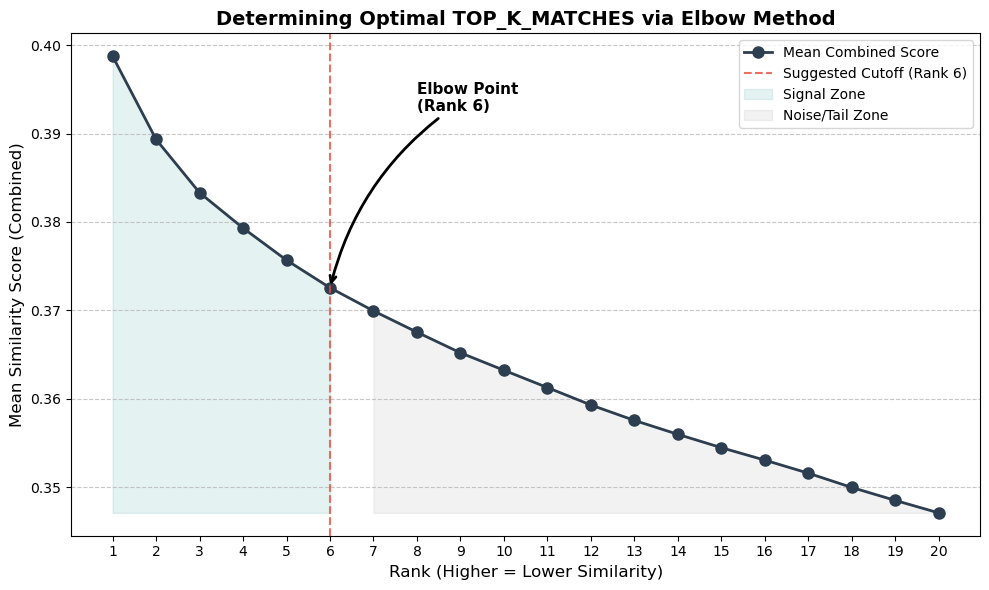

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '20_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top20_matches_all_scores.csv'
SAVE_PLOT = "rank_validation_elbow.png"

def find_elbow_geometric(x, y):
    """
    Finds the elbow point using the distance from the line connecting 
    the first and last points.
    """
    # Vector from first to last point
    n_points = len(x)
    first_point = np.array([x[0], y[0]])
    line_vec = np.array([x[-1], y[-1]]) - first_point
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))

    # Vector from first point to all points
    vec_from_first = np.array([x, y]).T - first_point

    # Distance to line: ||vec - (vec.line_norm) * line_norm||
    scalar_proj = np.dot(vec_from_first, line_vec_norm)
    vec_proj = np.outer(scalar_proj, line_vec_norm)
    dist_to_line = np.sqrt(np.sum((vec_from_first - vec_proj)**2, axis=1))

    # The elbow is the point with the maximum distance
    return x[np.argmax(dist_to_line)]

def run_analysis(file_path):
    # 1. Load data
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return

    # 2. Aggregate scores by Rank
    # We average across all genes and samples to find the 'global' cutoff
    rank_stats = df.groupby('rank')['combined_score'].mean().reset_index()
    
    ranks = rank_stats['rank'].values
    scores = rank_stats['combined_score'].values

    # 3. Calculate Elbow
    elbow_rank = find_elbow_geometric(ranks, scores)

    # 4. Plotting
    plt.figure(figsize=(10, 6))
    
    # Plot the scores
    plt.plot(ranks, scores, 'o-', color='#2c3e50', label='Mean Combined Score', linewidth=2, markersize=8)
    
    # Highlight the elbow
    plt.axvline(x=elbow_rank, color='#e74c3c', linestyle='--', alpha=0.8,
                label=f'Suggested Cutoff (Rank {elbow_rank})')
    
    plt.fill_between(ranks, scores.min(), scores, where=(ranks <= elbow_rank), 
                     color='teal', alpha=0.1, label='Signal Zone')
    plt.fill_between(ranks, scores.min(), scores, where=(ranks > elbow_rank), 
                     color='gray', alpha=0.1, label='Noise/Tail Zone')

    # Formatting
    plt.title('Determining Optimal TOP_K_MATCHES via Elbow Method', fontsize=14, fontweight='bold')
    plt.xlabel('Rank (Higher = Lower Similarity)', fontsize=12)
    plt.ylabel('Mean Similarity Score (Combined)', fontsize=12)
    plt.xticks(np.arange(1, 21, 1))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()

    # Annotation
    elbow_score = scores[np.where(ranks == elbow_rank)[0][0]]
    plt.annotate(f'Elbow Point\n(Rank {elbow_rank})', 
                 xy=(elbow_rank, elbow_score), 
                 xytext=(elbow_rank+2, elbow_score+0.02),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='black', lw=2),
                 fontsize=11, fontweight='bold')

    plt.tight_layout()
    #plt.savefig(SAVE_PLOT, dpi=300)
    print(f"Analysis complete. Optimal rank cutoff found at: {elbow_rank}")
    print(f"Plot saved as: {SAVE_PLOT}")
    plt.show()

if __name__ == "__main__":
    run_analysis(INPUT_FILE)